In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def load_dictionnary(post_processed_folder):	
	data = np.genfromtxt(post_processed_folder)

	dist = 152.6*3261563.7769443 # Mpc to ly

	dict_data = {'energy': data[:, 0],
				 'source_energy': data[:, 1],
				 'weight': data[:, 2],
				 'x': data[:, 3],
				 'y': data[:, 4],
				 'z': data[:, 5],
				 'x_final': data[:, 6],
				 'y_final': data[:, 7],
				 'z_final': data[:, 8],
				 'px': data[:, 9],
				 'py': data[:, 10],
				 'pz': data[:, 11],
				 'theta': data[:, 12],
				 'phi': data[:, 13],
				 't_delay': data[:, 14]*dist,  # convert to light years
				 'redshift': data[:, 15],
				 'prim': data[:, 16]}

	return dict_data

In [45]:
dict_data = load_dictionnary("../jeffrey_crbeam/MRK501_B1e-13")

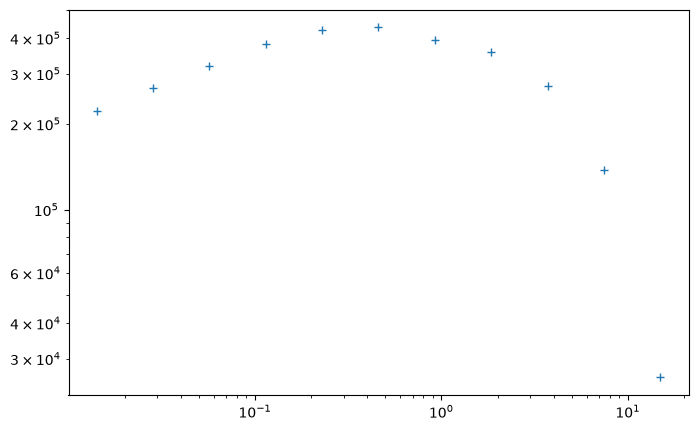

In [81]:
sec_mask = np.asarray(dict_data["prim"], dtype=float) != 1
energies = np.asarray(dict_data["energy"], dtype=float)[sec_mask] / 1e12
weights = np.asarray(dict_data["weight"], dtype=float)[sec_mask]

e_bins = np.logspace(np.log10(energies.min()), np.log10(energies.max()), 12)
e = np.sqrt(e_bins[:-1] * e_bins[1:])
de = np.diff(e_bins)
flux, _ = np.histogram(energies, bins=e_bins, weights=weights)
dnde = flux / de
sed = e**2 * dnde

plt.figure(figsize=(8, 5))
plt.plot(e, sed, "+")
plt.yscale("log")
plt.xscale("log")
plt.show()

I need to know probably what is the simulated time.
Also is this telescope simulated exposure or just simulated propagation of gamma rays.